# How much can we trust a model response? Does a model handle the aerosol-forced monsoon response realistically?

The goal is to estimate model uncertainity and check if SAI creates any signal (change>uncertainty), for \
    spatial rainfall anomalies or changes \
    ITCZ deviations or shifts 
- 20260218_JJAS_NDJF_PR_BIAS.ipynb : piControl versus Historical
- 20260220_JJAS_NDJF_PR_BIAS_SSP585.ipynb : Historical versus SSP585
- 20260221_JJAS_NDJF_PR_BIAS_SSP245.ipynb : Historical versus SSP245
- 20260221_JJAS_NDJF_PR_BIAS_G6Sulfur.ipynb : Historical versus G6sulfur

In [1]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt

Compute 

    JJAS and NDJF mean of OBS (TRMM)
    JJAS and NDJF for models : 
                                piControl, historical, SS585 bias (over historial) : bias

OBS - piControl: Tells you the model's baseline bias — how well the model simulates monsoon rainfall in the absence of any external forcing. This is the "pure" model structural error.

OBS - Historical: Tells you the model's bias in the forced climate — combining structural model error + how well the model responds to actual historical forcings.

Comparing the two: If (OBS - Historical) ≠ (OBS - piControl), it means the forcing response itself is biased — the model doesn't accurately simulate how monsoon rainfall changed due to anthropogenic/natural forcing, beyond its baseline structural errors.

In short: piControl bias = model's inherent error; Historical bias = model's inherent error + forcing response error. Their difference isolates the model's error in simulating forced monsoon changes.

piControl→Historical: Does anthropogenic forcing distort model skill? \
Historical→SSP585: Does intensified warming amplify/shift biases? \
Historical→SAI: Does cooling-based geoengineering create distinct bias patterns — i.e., does the model handle the aerosol-forced monsoon suppression realistically?


**Since all data needs to be in one grid resolution, I am regridding to 2.5x2.5 degrees**

I have 6 models:
1. Check consistency across models:
If all 6 models show similar (OBS-Historical) ≠ (OBS-piControl), it suggests a robust, systematic problem in how models respond to forcing — not a model-specific artifact.
2. Quantify the "forcing-induced bias change":
For each model, compute: **Δbias = (OBS-Historical) − (OBS-piControl)**
This isolates each model's error in simulating the forced response. Then compare Δbias across 6 models — do they agree in sign and magnitude?
3. Model ranking/weighting:
**Models where Δbias is small are better at simulating the forced monsoon response, and could be given higher weight in an ensemble for future projections.**
4. Identify inter-model spread:
If Δbias varies widely across the 6 models, it highlights uncertainty in how forcing affects monsoon — some models may overestimate, others underestimate the forced signal.
5. Bias stationarity assessment:
If a model's bias is stationary (OBS-Historical ≈ OBS-piControl), bias correction trained on historical period is more reliable for that model. Models with large Δbias violate stationarity — their bias corrections are less trustworthy for future scenarios.
This framework helps you select, weight, or flag models before using them for SAI or SSP585 projections.

I have historical from 1850-2014 and picontrol from 1850-2849 : I am planing to use 30year climatology of HIST and 30year climatology of picontrol and 30 year climatology of OBS. Now if there is a certain amount of uncertainty (standard deviation between mean of different 30 years of HIST and same for picontrol), how do I use that uncertainty information to assess Δbias?

**Setting up the uncertainty:**

- From Historical (1850–2014): You have limited non-overlapping 30-year windows (e.g., ~5 windows). Compute mean climatology for each → get spread (SD) across these means = **uncertainty in HIST climatology (σ_hist)**
- From piControl (1850–2849): You have many non-overlapping 30-year windows (~33 windows). Compute mean climatology for each → SD across these = **uncertainty in piControl climatology (σ_pi)**
- OBS is fixed (one 30-year climatology), so it has no sampling uncertainty in this framework.

**Assessing Δbias with uncertainty:**

Δbias = (OBS − HIST) − (OBS − piControl) = **piControl_mean − HIST_mean**

Uncertainty in Δbias:
**σ_Δbias = √(σ_hist² + σ_pi²)**

**Key assessment:**

- If **|Δbias| > σ_Δbias** (or use 2σ for 95% confidence): the forcing-induced bias change is **statistically significant** — the model genuinely responds differently to forcing.
- If **|Δbias| ≤ σ_Δbias**: the difference could simply be due to **internal variability**, not forcing — Δbias is not distinguishable from noise.

**Across 6 models:**
Check how many models show significant Δbias — if most do, the forced bias change is robust across the ensemble, strengthening your conclusion that:

**The model's bias is not stationary — it genuinely changes due to external forcing, beyond what internal variability alone can explain.**

Specifically, if most of the 6 models show significant Δbias, you can robustly conclude that:

- Historical forcing (anthropogenic + natural) systematically shifts model bias in simulating monsoon rainfall
- This shift is not just random internal variability — it reflects the model's **structural inability to correctly respond to forcing**
- Therefore, bias correction assuming stationarity (i.e., same bias in past and future) is **unreliable** for these models
- And by extension, projections under SSP585 or SAI from these models carry an additional layer of uncertainty beyond just spread across models

If you use multiple observational datasets (e.g., GPCP, TRMM, ERA5) for the same 30-year period, you get observational uncertainty (σ_obs) from the spread across them.
Then Δbias uncertainty becomes:
**σ_Δbias = √(σ_hist² + σ_pi² + 2·σ_obs²)**
(σ_obs appears twice because OBS enters both (OBS−HIST) and (OBS−piControl))

In [2]:
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means

In [3]:
import xarray as xr
from pathlib import Path

In [4]:
import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

In [5]:
# =========================
# User-defined metadata
# =========================

varname = "pr"

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")
TRMM_PATH = Path("/badc/trmm/data/TRMM_3B42")

In [6]:
#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


In [7]:
#Experiment details
EXPERIMENTS = {
    # "piControl":     {"project": "CMIP",        "scenario": "piControl",  "color": "black"},
    "HIST":          {"project": "CMIP",        "scenario": "historical", "color": "black"},
    # "SSP245":        {"project": "ScenarioMIP", "scenario": "ssp245"},
    # "SSP585":        {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":       {"project": "GeoMIP",      "scenario": "G6solar"},
    # "G6sulfur":      {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

In [8]:
all_results = {}

for model_name, model_meta in MODELS.items():

    var = {}
    var_by_year = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():

        if model_name == "CESM2-WACCM":
            if meta["scenario"] == "G6sulfur":
                ensemble = "r1i1p1f2"
            else:
                ensemble = "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        base = (
            CEDA_BASE
            / meta["project"]
            / model_meta["institution"]
            / model_name
            / meta["scenario"]
            / ensemble
            / "Amon"
            / varname
            / model_meta["grid"]
            / "latest"
        )
        print(str(base))

        if model_name == "CESM2-WACCM":
            ds = mf.open_files(str(base))
        elif model_name == "IPSL-CM6A-LR":
            ds = mf.open_files(str(base))
        else:
            ds = mf.open_files(str(base))

        var[exp] = mf.read_var(ds, varname)

    # ----------------------------
    # 2) SUBSET TO 1985-2014 AND SEASONAL MEANS
    # ----------------------------
    for exp, da in var.items():
        # Subset to 1985-2014
        da_subset = da.sel(time=slice('1985-01-01', '2014-12'))

        var_by_year[exp] = {
            "SUM": mf.seasonal_mean_by_year_old(da_subset, 6, 9),
            "WIN": mf.seasonal_mean_by_year_old(da_subset, 11, 2)
        }

    # ----------------------------
    # 3) 30-YR CLIMATOLOGY (no blocks)
    # ----------------------------
    results = {}

    for exp in var_by_year:
        results[exp] = {}

        for season in ["SUM", "WIN"]:
            da_year = var_by_year[exp][season]
            # Simple mean over all years — no blocks needed
            clim_mean = da_year.mean('year').compute()
            results[exp][season] = {
                "mean": clim_mean,
            }

    # ----------------------------
    # 4) Store HIST means
    # ----------------------------
    if "HIST" in results:
        results["mean_hist"] = {
            season: results["HIST"][season]["mean"]
            for season in ["SUM", "WIN"]
        }

    # Save results for this model
    all_results[model_name] = results
    print(f"{model_name}: done")

/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/latest
UKESM1-0-LL: done
/badc/cmip6/data/CMIP6/CMIP/CNRM-CERFACS/CNRM-ESM2-1/historical/r1i1p1f2/Amon/pr/gr/latest
CNRM-ESM2-1: done
/badc/cmip6/data/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/latest
MPI-ESM1-2-LR: done
/badc/cmip6/data/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r1i1p1f1/Amon/pr/gn/latest


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'pr' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


CESM2-WACCM: done
/badc/cmip6/data/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/r1i1p1f1/Amon/pr/gr/latest
IPSL-CM6A-LR: done


In [9]:
# Number of models
print(len(all_results))

# Number of experiments per model
for model_name, results in all_results.items():
    print(f"{model_name}: {len(results)} keys → {list(results.keys())}")

# Shape of actual data arrays
for model_name, results in all_results.items():
    print(f"{model_name} HIST SUM mean: {results['HIST']['SUM']['mean'].shape}")

5
UKESM1-0-LL: 2 keys → ['HIST', 'mean_hist']
CNRM-ESM2-1: 2 keys → ['HIST', 'mean_hist']
MPI-ESM1-2-LR: 2 keys → ['HIST', 'mean_hist']
CESM2-WACCM: 2 keys → ['HIST', 'mean_hist']
IPSL-CM6A-LR: 2 keys → ['HIST', 'mean_hist']
UKESM1-0-LL HIST SUM mean: (144, 192)
CNRM-ESM2-1 HIST SUM mean: (128, 256)
MPI-ESM1-2-LR HIST SUM mean: (96, 192)
CESM2-WACCM HIST SUM mean: (192, 288)
IPSL-CM6A-LR HIST SUM mean: (143, 144)


# TRMM

In [10]:
from pyhdf.SD import SD, SDC
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

def read_trmm_file(filepath):
    """
    Read a single TRMM 3B42 HDF4 file.
    Returns xarray DataArray with (lat, lon) in mm/hr.
    """
    hdf = SD(str(filepath), SDC.READ)
    
    precip = hdf.select('precipitation').get()  # shape (1440, 400) = (nlon, nlat)
    
    # Transpose to (nlat, nlon)
    precip = precip.T  # now (400, 1440)

    # TRMM 3B42 standard grid
    lat = np.arange(-49.875, 49.876, 0.25)   # 400 points
    lon = np.arange(-179.875, 179.876, 0.25)  # 1440 points

    da = xr.DataArray(
        precip,
        dims=['lat', 'lon'],
        coords={'lat': lat, 'lon': lon}
    )

    # Fill value
    fill_value = hdf.select('precipitation').attributes().get('_FillValue', -9999.9)
    da = da.where(da != fill_value)

    hdf.end()
    return da  # mm/hr


def load_trmm_season(years, season='SUM', trmm_base='/badc/trmm/data/TRMM_3B42'):
    """
    Load TRMM 3B42 data and compute seasonal mean for given years.
    
    Parameters:
    -----------
    years    : list of years e.g. range(1998, 2020)
    season   : 'SUM' (JJAS: months 6-9) or 'WIN' (NDJF: months 11,12,1,2)
    trmm_base: base path to TRMM data
    
    Returns:
    --------
    seasonal_mean : xarray DataArray (lat, lon) in mm/day
    """
    trmm_base = Path(trmm_base)

    if season == 'SUM':
        target_months = [6, 7, 8, 9]
    elif season == 'WIN':
        target_months = [11, 12, 1, 2]
    else:
        raise ValueError("season must be 'SUM' or 'WIN'")

    all_daily = []

    for year in years:
        print(f"  Processing year {year}...")

        # Generate all dates for this year
        dates = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')

        for date in dates:
            if date.month not in target_months:
                continue

            # Day of year (TRMM uses DOY folders)
            doy = date.strftime('%j')  # e.g. '001', '002'
            day_dir = trmm_base / str(year) / doy

            if not day_dir.exists():
                print(f"    Missing: {day_dir}")
                continue

            # Collect all 8 3-hourly files for this day
            date_str = date.strftime('%Y%m%d')
            hours = ['03', '06', '09', '12', '15', '18', '21', '00']

            # '00' belongs to next day's file naming
            daily_slices = []
            for hr in hours:
                if hr == '00':
                    # 00 UTC file is named with next day
                    next_date = date + pd.Timedelta(days=1)
                    next_doy  = next_date.strftime('%j')
                    next_dir  = trmm_base / str(next_date.year) / next_doy
                    fname = next_dir / f"3B42.{next_date.strftime('%Y%m%d')}.{hr}.7.HDF"
                else:
                    fname = day_dir / f"3B42.{date_str}.{hr}.7.HDF"

                if not fname.exists():
                    continue

                try:
                    da = read_trmm_file(fname)
                    daily_slices.append(da)
                except Exception as e:
                    print(f"    Error reading {fname}: {e}")
                    continue

            if len(daily_slices) > 0:
                # Daily mean from 3-hourly slices
                daily_mean = xr.concat(daily_slices, dim='time').mean('time')
                all_daily.append(daily_mean)

    if len(all_daily) == 0:
        raise ValueError(f"No TRMM data found for season {season}, years {list(years)}")

    # Stack all daily means and compute seasonal mean
    stacked       = xr.concat(all_daily, dim='time')
    seasonal_mean = stacked.mean('time') * 24  # mm/hr → mm/day

    return seasonal_mean


def load_trmm_seasonal_means(years=range(1998, 2020),
                              trmm_base='/badc/trmm/data/TRMM_3B42'):
    """
    Load TRMM JJAS and NDJF seasonal means.
    Returns dict with 'SUM' and 'WIN' DataArrays in mm/day.
    """
    trmm_means = {}
    for season in ['SUM', 'WIN']:
        print(f"Loading TRMM {season}...")
        trmm_means[season] = load_trmm_season(years, season=season,
                                               trmm_base=trmm_base)
        print(f"TRMM {season} done: shape {trmm_means[season].shape}")
    return trmm_means

In [11]:
# Usage
trmm_means = load_trmm_seasonal_means(years=range(1998, 2020))

Loading TRMM SUM...
  Processing year 1998...
  Processing year 1999...
  Processing year 2000...
  Processing year 2001...
  Processing year 2002...
  Processing year 2003...
  Processing year 2004...
  Processing year 2005...
  Processing year 2006...
  Processing year 2007...
  Processing year 2008...
  Processing year 2009...
  Processing year 2010...
  Processing year 2011...
  Processing year 2012...
  Processing year 2013...
  Processing year 2014...
  Processing year 2015...
  Processing year 2016...
  Processing year 2017...
  Processing year 2018...
  Processing year 2019...
TRMM SUM done: shape (400, 1440)
Loading TRMM WIN...
  Processing year 1998...
  Processing year 1999...
  Processing year 2000...
  Processing year 2001...
  Processing year 2002...
  Processing year 2003...
  Processing year 2004...
  Processing year 2005...
  Processing year 2006...
  Processing year 2007...
  Processing year 2008...
  Processing year 2009...
  Processing year 2010...
  Processing year

In [12]:
trmm_means

{'SUM': <xarray.DataArray (lat: 400, lon: 1440)> Size: 2MB
 array([[0.6861403 , 0.6910368 , 0.7157039 , ..., 0.7420608 , 0.74968696,
         0.7382755 ],
        [0.70594853, 0.6842581 , 0.7102406 , ..., 0.7149925 , 0.7273836 ,
         0.7328254 ],
        [0.6576624 , 0.6898018 , 0.7002259 , ..., 0.72183937, 0.6940175 ,
         0.6719185 ],
        ...,
        [2.8919566 , 2.9161258 , 2.8341408 , ..., 3.0569463 , 3.0624151 ,
         2.9927437 ],
        [2.9086895 , 2.859074  , 2.822261  , ..., 2.9629803 , 3.0328546 ,
         2.9266257 ],
        [2.862576  , 2.7685328 , 2.7432394 , ..., 2.9649973 , 2.9766746 ,
         2.8936913 ]], shape=(400, 1440), dtype=float32)
 Coordinates:
   * lat      (lat) float64 3kB -49.88 -49.62 -49.38 -49.12 ... 49.38 49.62 49.88
   * lon      (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9,
 'WIN': <xarray.DataArray (lat: 400, lon: 1440)> Size: 2MB
 array([[1.7173587, 1.7188709, 1.7247174, ..., 1.6793299, 1.6997318,
         1.68545

In [13]:
import xesmf as xe
import xarray as xr
import numpy as np

def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 

def compute_bias_wrt_trmm(all_results, trmm_means, season='SUM'):
    """
    Compute bias = MODEL_HIST - TRMM for each model.
    Regrids model to TRMM grid (or TRMM to model grid).
    Returns dict {model_name: bias DataArray}
    """
    bias = {}

    # Regrid TRMM to common grid once
    trmm = regrid_to_common(trmm_means[season], target_lat=50)
    # Convert TRMM lon from -180:180 to 0:360 if needed
    # trmm = trmm.assign_coords(lon=(trmm.lon % 360)).sortby('lon')

    for model_name, results in all_results.items():
        if 'HIST' not in results:
            continue

        model_mean = results['HIST'][season]['mean'].compute() * 86400  # kg/m2/s → mm/day
        model_regridded = regrid_to_common(model_mean, target_lat=50)

        bias[model_name] = model_regridded - trmm
        print(f"{model_name} {season}: bias computed")

    return bias

In [14]:
# Bias calculation
bias_SUM = compute_bias_wrt_trmm(all_results, trmm_means, season='SUM')
bias_WIN = compute_bias_wrt_trmm(all_results, trmm_means, season='WIN')

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


UKESM1-0-LL SUM: bias computed
CNRM-ESM2-1 SUM: bias computed
MPI-ESM1-2-LR SUM: bias computed
CESM2-WACCM SUM: bias computed
IPSL-CM6A-LR SUM: bias computed


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


UKESM1-0-LL WIN: bias computed
CNRM-ESM2-1 WIN: bias computed
MPI-ESM1-2-LR WIN: bias computed
CESM2-WACCM WIN: bias computed
IPSL-CM6A-LR WIN: bias computed


In [15]:
bias_SUM

{'UKESM1-0-LL': <xarray.DataArray (lat: 41, lon: 144)> Size: 24kB
 array([[ 0.        ,  3.5421698 ,  3.566423  , ...,  3.2243125 ,
          3.2655377 ,  3.3470123 ],
        [-1.910384  ,  2.057457  ,  2.2766864 , ...,  1.9082811 ,
          1.9687779 ,  1.8199458 ],
        [-2.5528514 ,  1.5440478 ,  1.4669044 , ...,  1.4243991 ,
          1.561379  ,  1.7847984 ],
        ...,
        [-1.8388295 , -0.96173036, -0.6463187 , ..., -0.911929  ,
         -0.8399288 , -0.6934363 ],
        [-1.8082325 , -0.5743121 ,  0.0088973 , ..., -1.0356269 ,
         -0.9778932 , -0.73734295],
        [ 0.        ,  1.1101081 ,  1.4553032 , ...,  1.2188433 ,
          1.2054901 ,  1.1137468 ]], shape=(41, 144), dtype=float32)
 Coordinates:
   * lat      (lat) float64 328B -50.0 -47.5 -45.0 -42.5 ... 42.5 45.0 47.5 50.0
   * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5,
 'CNRM-ESM2-1': <xarray.DataArray (lat: 41, lon: 144)> Size: 24kB
 array([[ 3.14895   ,  3.3020039 

In [16]:

def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')

def plot_multimodel_bias(bias_SUM, bias_WIN, trop_bound=None, agree_threshold=4,
                          vmax=5.0, savefig=None):
    """
    Multi-model mean bias (MODEL - TRMM) stitched NH: JJAS, SH: NDJF.
    bias_SUM, bias_WIN: {model_name: DataArray} in mm/day
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

    if trop_bound is None:
        trop_bound = 50

    # def get_mm_mean_and_agreement(bias_dict):
    #     bias_list = []
    #     for model_name, da in bias_dict.items():
    #         da_regridded = regrid_to_common(da, target_lat=trop_bound)
    #         bias_list.append(da_regridded)
    #         print(f"{model_name}: regridded to {da_regridded.shape}")
    #     stacked    = xr.concat(bias_list, dim='model')
    #     mm_mean    = stacked.mean('model')
    #     n_positive = (stacked > 0).sum('model')
    #     n_negative = (stacked < 0).sum('model')
    #     agreement  = (n_positive >= agree_threshold) | (n_negative >= agree_threshold)
    #     return mm_mean, agreement, len(bias_list)

    def get_mm_mean_and_agreement(bias_dict):
        bias_list = []
        for model_name, da in bias_dict.items():
            da_regridded = regrid_to_common(da, target_lat=trop_bound)
            da_rolled    = roll_lon(da_regridded)  # ADD THIS
            bias_list.append(da_rolled)
            print(f"{model_name}: regridded to {da_rolled.shape}")
        stacked    = xr.concat(bias_list, dim='model')
        mm_mean    = stacked.mean('model')
        n_positive = (stacked > 0).sum('model')
        n_negative = (stacked < 0).sum('model')
        agreement  = (n_positive >= agree_threshold) | (n_negative >= agree_threshold)
        return mm_mean, agreement, len(bias_list)

    mm_SUM, agree_SUM, n_models = get_mm_mean_and_agreement(bias_SUM)
    mm_WIN, agree_WIN, _        = get_mm_mean_and_agreement(bias_WIN)

    # Stitch NH=JJAS, SH=NDJF
    lat = mm_SUM.lat
    mm_stitched    = xr.where(lat > 0, mm_SUM,    mm_WIN)
    agree_stitched = xr.where(lat > 0, agree_SUM, agree_WIN)

    lon = mm_stitched.lon

    fig, ax = plt.subplots(1, 1, figsize=(10, 5),
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)

    levels = np.linspace(-vmax, vmax, 21)
    im = ax.contourf(lon, lat, mm_stitched, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

    # Stipple
    sig_lat, sig_lon = np.where(agree_stitched.values)
    ax.scatter(lon.values[sig_lon], lat.values[sig_lat],
               s=0.5, c='k', alpha=0.5, transform=ccrs.PlateCarree())

    # Equator line
    ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())

    ax.set_extent([float(lon.min()), float(lon.max()),
                   float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')

    ax.set_xticks(np.arange(np.floor(float(lon.min())),
                            np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(np.floor(float(lat.min())),
                            np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=8)

    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05,
                 shrink=1.0, aspect=40,
                 label='Bias (MODEL $-$ TRMM) (mm day$^{-1}$)')

    # Bombardi and Boos 2021 regions
    regions = {
        'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
        'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
        'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
        'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
        'India':        {'lon': (73,  87),   'lat': (15,    27)},
        'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
    }
    for name, coords in regions.items():
        lon0, lon1 = coords['lon']
        lat0, lat1 = coords['lat']
        rect = mpatches.Rectangle(
            (lon0, lat0), lon1-lon0, lat1-lat0,
            linewidth=1.2, edgecolor='black', facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
        ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                fontsize=8, ha='center', va='top',
                transform=ccrs.PlateCarree())

    ax.set_title(
        f'Multi-model mean bias (MODEL $-$ TRMM) (NH: JJAS | SH: NDJF)\n'
        f'Stippling: ≥{agree_threshold}/{n_models} models agree on sign',
        fontsize=11
    )

    plt.tight_layout()
    if savefig:
        plt.savefig(savefig, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

UKESM1-0-LL: regridded to (25, 144)
CNRM-ESM2-1: regridded to (25, 144)
MPI-ESM1-2-LR: regridded to (25, 144)
CESM2-WACCM: regridded to (25, 144)
IPSL-CM6A-LR: regridded to (25, 144)
UKESM1-0-LL: regridded to (25, 144)
CNRM-ESM2-1: regridded to (25, 144)
MPI-ESM1-2-LR: regridded to (25, 144)
CESM2-WACCM: regridded to (25, 144)
IPSL-CM6A-LR: regridded to (25, 144)


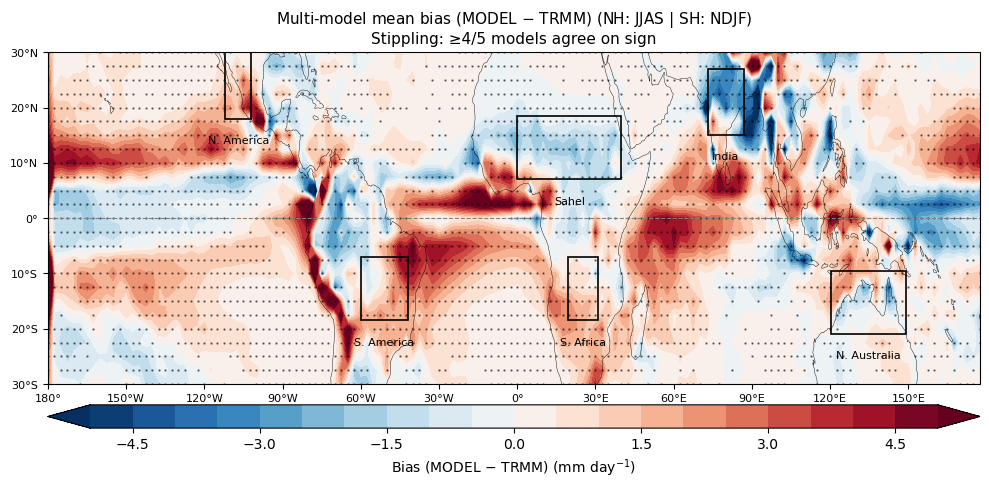

In [17]:
# Usage
fig = plot_multimodel_bias(bias_SUM, bias_WIN, trop_bound=30,
                            agree_threshold=4, vmax=5.0,
                            savefig='multimodel_bias_TRMM.png')

In [18]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import xarray as xr
# from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# def plot_delta_bias(results, season='SUM', model_name='Model'):
#     """
#     Plot delta_bias, |delta_bias|, sigma_delta_bias, and significance mask
#     """
#     delta_bias = results['delta_bias'][season].compute()
#     sigma = results['delta_bias_sd'][season].compute()
    
#     # Significance mask: where |Δbias| > σ_Δbias (2*sigma for 95%)
#     significant = np.abs(delta_bias) > sigma
    
#     lat = delta_bias.lat
#     lon = delta_bias.lon
    
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5),
#                               subplot_kw={'projection': ccrs.PlateCarree(180)})

#     for ax in axes:
#         ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    
#     titles = [
#         f'$\\Delta$bias$_{{HIST-piCtrl}}$ ({season})',
#         f'$\\sigma_{{\\Delta bias}}$ - |$\\Delta$bias| ({season})',
#         f'$\\sigma_{{\\Delta bias}}$ ({season})'
#     ]
#     data_list = [delta_bias, sigma-np.abs(delta_bias), sigma]
    
#     # Colormaps
#     # cmaps = ['RdBu_r', 'Reds', 'Oranges'] ;#different colormaps
#     cmaps = ['RdBu_r', 'RdBu_r', 'RdBu_r'] ;#same colormap because I am using same vmax-vmin
    
    
#     for i, (ax, data, title, cmap) in enumerate(zip(axes, data_list, titles, cmaps)):
#         ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
#         # ax.add_feature(cfeature.BORDERS, linewidth=0.3)

#         #-----------------------------
#         # symmetric colorbar for Δbias
#         #-----------------------------

#         #------Using pcolormesh--------
#         # if i == 0:
#         #     vmax = float(np.nanpercentile(np.abs(data.values), 95))
#         #     norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
#         #     im = ax.pcolormesh(lon, lat, data, cmap=cmap, norm=norm,
#         #                        transform=ccrs.PlateCarree())
#         # else:
#         #     vmax = float(np.nanpercentile(data.values, 95))
#         #     im = ax.pcolormesh(lon, lat, data, cmap=cmap, vmin=0, vmax=vmax,
#         #                        transform=ccrs.PlateCarree())

#         #------Using contourf--------

#         #-----------------------------
#         # commenting the bellow block
#         # using symmetric colorbar for all plots vmax=0.5, vmin=-0.5
#         #-----------------------------
#         # if i == 0:
#         #     vmax = float(np.nanpercentile(np.abs(data.values), 95))
#         #     levels = np.linspace(-vmax, vmax, 21)
#         #     im = ax.contourf(lon, lat, data, levels=levels, cmap=cmap,
#         #                      extend='both', transform=ccrs.PlateCarree())
#         # else:
#         #     vmax = float(np.nanpercentile(data.values, 95))
#         #     levels = np.linspace(0, vmax, 21)
#         #     im = ax.contourf(lon, lat, data, levels=levels, cmap=cmap,
#         #                      extend='max', transform=ccrs.PlateCarree())
#         vmax=0.5
#         vmin=-vmax
#         levels = np.linspace(vmin, vmax, 21)
#         im = ax.contourf(lon, lat, data, levels=levels, cmap=cmap,
#                          extend='both', transform=ccrs.PlateCarree())
        
#         # Stipple where significant (only on Δbias and |Δbias| panels)
#         if i in [0, 1]:
#             sig_lat, sig_lon = np.where(significant.values)
#             ax.scatter(lon.values[sig_lon], lat.values[sig_lat],
#                       s=1.5, c='lime', alpha=1.0, transform=ccrs.PlateCarree())
        
#         plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05,aspect=40,
#                     label='mm/day' if 'units' not in str(data) else 'kg m⁻² s⁻¹')
#         ax.set_title(title, fontsize=12)
#         # ax.set_global()
#         ax.set_extent([float(lon.min()), float(lon.max()), 
#                float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
#         ax.set_aspect('auto')

#         ax.set_xticks(np.arange(np.floor(lon.min()), np.ceil(lon.max())+1, 30), crs=ccrs.PlateCarree())
#         ax.set_yticks(np.arange(np.floor(lat.min()), np.ceil(lat.max())+1, 10), crs=ccrs.PlateCarree())
#         ax.xaxis.set_major_formatter(LongitudeFormatter())
#         ax.yaxis.set_major_formatter(LatitudeFormatter())
#         ax.tick_params(labelsize=8)
    
#     plt.suptitle(f'{model_name} — Forcing-induced bias change', fontsize=14, y=1.02)
#     plt.tight_layout()
#     # plt.savefig(f'delta_bias_{season}_{model_name}.png', dpi=150, bbox_inches='tight')
#     plt.show()



In [23]:
# def compute_results(all_results, lat_slice=None, lon_slice=None):
#     """
#     Optionally subset and compute all dask arrays in all_results dict (all models).
    
#     Parameters:
#     -----------
#     all_results : dict of {model_name: results_dict} with dask arrays
#     lat_slice : tuple e.g. (-30, 30) or None for global
#     lon_slice : tuple e.g. (60, 100) or None
    
#     Returns:
#     --------
#     all_results_computed : dict of {model_name: computed results}
#     """
#     import dask

#     def subset(da):
#         if lat_slice is not None:
#             da = da.sel(lat=slice(*lat_slice))
#         if lon_slice is not None:
#             da = da.sel(lon=slice(*lon_slice))
#         return da

#     lazy_all = {}
#     for model_name, results in all_results.items():
#         lazy_all[model_name] = {
#             'piControl': {
#                 'SUM': {'mean': subset(results['piControl']['SUM']['mean']),
#                         'sd':   subset(results['piControl']['SUM']['sd'])},
#                 'WIN': {'mean': subset(results['piControl']['WIN']['mean']),
#                         'sd':   subset(results['piControl']['WIN']['sd'])}
#             },
#             'HIST': {
#                 'SUM': {'mean': subset(results['HIST']['SUM']['mean']),
#                         'sd':   subset(results['HIST']['SUM']['sd'])},
#                 'WIN': {'mean': subset(results['HIST']['WIN']['mean']),
#                         'sd':   subset(results['HIST']['WIN']['sd'])}
#             },
#             'delta_bias':    {'SUM': subset(results['delta_bias']['SUM']),
#                               'WIN': subset(results['delta_bias']['WIN'])},
#             'delta_bias_sd': {'SUM': subset(results['delta_bias_sd']['SUM']),
#                               'WIN': subset(results['delta_bias_sd']['WIN'])}
#         }

#     return dask.compute(lazy_all)[0]


# # # Usage
# # all_results_tropics = compute_results(all_results, lat_slice=(-50, 50))
# # all_results_SA      = compute_results(all_results, lat_slice=(5, 40), lon_slice=(60, 100))
# # all_results_global  = compute_results(all_results)

# # # Then plot per model
# # for model_name, results in all_results_tropics.items():
# #     plot_delta_bias(results, season='SUM', model_name=model_name)

In [24]:
# # Slice for tropics
# trop_lat=30
# all_results_tropics  = compute_results(all_results, lat_slice=(-trop_lat, trop_lat))


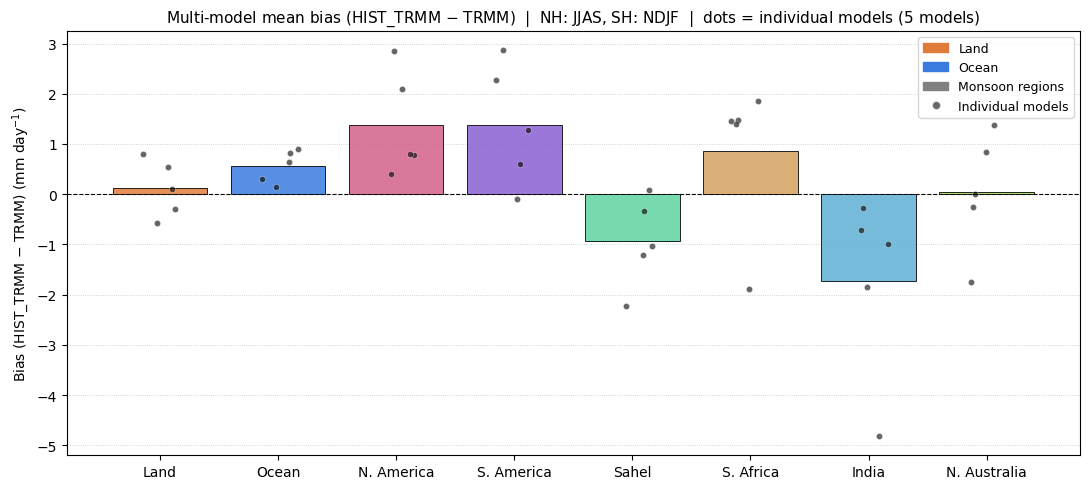

Returning → bar_data_HIST_TRMM19852014_minus_TRMM


In [22]:
def _exp_year_label(exp_name):
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    elif exp_name == "HIST_TRMM":       # HIST when validated against TRMM
        return "19852014"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")

def compute_regional_bar_bias(
    bias_SUM,
    bias_WIN,
    exp_name="HIST",
    obs_name="TRMM",
    trop_bound=30,
    land_mask=None,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    """
    Compute regional bar data for (MODEL - OBS) bias.

    Parameters
    ----------
    bias_SUM, bias_WIN : dict {model_name: DataArray}
        Per-model bias fields in mm/day (already exp - obs).
    exp_name : str
        Experiment name, e.g. 'HIST'.
    obs_name : str
        Observational dataset name, e.g. 'TRMM'.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import xarray as xr
    import warnings

    exp_label = f"{exp_name}{_exp_year_label(exp_name)}"
    var_name  = f"bar_data_{exp_label}_minus_{obs_name}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model stitched bias fields
    # ------------------------------------------------------------------ #
    delta_list = []
    for model_name in bias_SUM:
        if model_name not in bias_WIN:
            warnings.warn(f"Model '{model_name}' missing from bias_WIN — skipped.")
            continue

        da_SUM = roll_lon(regrid_to_common(bias_SUM[model_name], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(bias_WIN[model_name], target_lat=trop_bound))

        lat      = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError("No models found in bias_SUM/bias_WIN.")

    stacked = xr.concat(delta_list, dim="model")
    lat     = stacked.lat.values
    lon     = stacked.lon.values

    # ------------------------------------------------------------------ #
    # 2.  Land / ocean mask
    # ------------------------------------------------------------------ #
    if land_mask is None:
        try:
            import regionmask
            land_110     = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            mask_np      = land_110.mask(lon, lat)
            land_mask_da = xr.DataArray(~np.isnan(mask_np.values),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
        except ImportError:
            warnings.warn("regionmask not found — using all-ocean proxy.")
            land_mask_da = xr.DataArray(np.zeros((len(lat), len(lon)), dtype=bool),
                                        dims=["lat", "lon"],
                                        coords={"lat": lat, "lon": lon})
    else:
        land_mask_da = land_mask.interp(lat=lat, lon=lon, method="nearest") > 0.5

    ocean_mask_da = ~land_mask_da

    # ------------------------------------------------------------------ #
    # 3.  Monsoon region boxes
    # ------------------------------------------------------------------ #
    regions = {
        "N. America":   {"lon": (248, 258),   "lat": (18,    33)},
        "S. America":   {"lon": (300, 318),   "lat": (-18.5, -7)},
        "Sahel":        {"lon": (0,   40),    "lat": (7,   18.5)},
        "S. Africa":    {"lon": (19.5, 31),   "lat": (-18.5, -7)},
        "India":        {"lon": (73,  87),    "lat": (15,    27)},
        "N. Australia": {"lon": (120.5, 149), "lat": (-21,  -9.5)},
    }

    # ------------------------------------------------------------------ #
    # 4.  Area-weighted means
    # ------------------------------------------------------------------ #
    weights    = np.cos(np.deg2rad(lat))
    weights_da = xr.DataArray(weights, dims=["lat"], coords={"lat": lat})

    def area_mean(data_3d, mask_2d):
        masked = data_3d.where(mask_2d)
        w      = weights_da.where(mask_2d)
        return (masked * w).sum(["lat", "lon"]) / w.sum(["lat", "lon"])

    def to_180(l):
        return ((l + 180) % 360) - 180

    def box_mask(lon_range, lat_range):
        lon0, lon1 = to_180(lon_range[0]), to_180(lon_range[1])
        lat0, lat1 = lat_range
        lon_da, lat_da = stacked.lon, stacked.lat
        if lon0 <= lon1:
            lon_sel = (lon_da >= lon0) & (lon_da <= lon1)
        else:
            lon_sel = (lon_da >= lon0) | (lon_da <= lon1)
        return lon_sel & (lat_da >= lat0) & (lat_da <= lat1)

    labels        = []
    means         = []
    colors        = []
    per_model_all = []

    land_ocean = [("Land",  land_mask_da,  "#E07B3A"),
                  ("Ocean", ocean_mask_da, "#3A7BE0")]
    region_colors = ["#D45F8B", "#8B5FD4", "#5FD4A0",
                     "#D4A05F", "#5FAFD4", "#A0D45F"]

    for label, mask, color in land_ocean:
        pm = area_mean(stacked, mask).values
        labels.append(label)
        means.append(float(np.nanmean(pm)))
        colors.append(color)
        per_model_all.append(pm)

    for (rname, coords), rcol in zip(regions.items(), region_colors):
        bmask = box_mask(coords["lon"], coords["lat"])
        pm    = area_mean(stacked, bmask).values
        labels.append(rname)
        means.append(float(np.nanmean(pm)))
        colors.append(rcol)
        per_model_all.append(pm)

    means = np.array(means)
    x     = np.arange(len(labels))

    # ------------------------------------------------------------------ #
    # 5.  Plot (optional)
    # ------------------------------------------------------------------ #
    fig = None
    if plot:
        fig, ax = plt.subplots(figsize=(11, 5))

        ax.bar(x, means, color=colors, edgecolor="k",
               linewidth=0.7, alpha=0.85, zorder=3)

        rng      = np.random.default_rng(42)
        n_models = len(delta_list)
        for i, pm in enumerate(per_model_all):
            jitter = rng.uniform(-0.18, 0.18, size=len(pm))
            ax.scatter(x[i] + jitter, pm, color="k", s=20,
                       zorder=5, alpha=0.6, linewidths=0.4, edgecolors="white")

        ax.axhline(0, color="k", linewidth=0.8, linestyle="--", zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel(f"Bias ({exp_name} $-$ {obs_name}) (mm day$^{{-1}}$)", fontsize=10)
        ax.set_title(
            f"Multi-model mean bias ({exp_name} $-$ {obs_name})"
            f"  |  NH: JJAS, SH: NDJF  |  "
            f"dots = individual models ({n_models} models)",
            fontsize=11)
        ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7, zorder=1)

        legend_patches = [
            mpatches.Patch(color="#E07B3A", label="Land"),
            mpatches.Patch(color="#3A7BE0", label="Ocean"),
            mpatches.Patch(color="grey",    label="Monsoon regions"),
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="k",
                       markersize=6, alpha=0.6, label="Individual models"),
        ]
        ax.legend(handles=legend_patches, fontsize=9, loc="upper right")
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    # ------------------------------------------------------------------ #
    # 6.  Package and return
    # ------------------------------------------------------------------ #
    bar_data = {
        "labels":        labels,
        "means":         means,
        "colors":        colors,
        "per_model_all": per_model_all,
    }

    print(f"Returning → {var_name}")
    return bar_data, var_name


bar_data, name = compute_regional_bar_bias(bias_SUM, bias_WIN,
                                            exp_name="HIST_TRMM", obs_name="TRMM")
globals()[name] = bar_data
# stored as bar_data_HIST_TRMM19852014_minus_TRMM

In [25]:
%store bar_data_HIST_TRMM19852014_minus_TRMM

Stored 'bar_data_HIST_TRMM19852014_minus_TRMM' (dict)
